In [25]:
# ==============================================================================
# CELDA 1: INSTALACIÓN DE DEPENDENCIAS Y CONFIGURACIÓN GRÁFICA HEADLESS
# ==============================================================================
import os
print("Instalando el entorno físico de MuJoCo y dependencias de video...")
!pip install -q mujoco mediapy scipy matplotlib
!pip install control

# Forzar el uso del backend gráfico EGL en los servidores de Google Colab
os.environ['MUJOCO_GL'] = 'egl'

import numpy as np
import scipy.linalg
import scipy.signal
import mujoco
import mediapy as media
import matplotlib.pyplot as plt

print("✓ Dependencias listas y backend gráfico configurado correctamente.")

Instalando el entorno físico de MuJoCo y dependencias de video...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 11.4 MB/s eta 0:00:00
✓ Dependencias listas y backend gráfico configurado correctamente.


In [14]:
# ==============================================================================
# CELDA 2: PARÁMETROS FÍSICOS Y ÁRBOL GEOMÉTRICO EN FORMATO MJCF/XML
# ==============================================================================
# Parámetros analíticos reales del exoesqueleto de 2 GDL (Muslo y Pierna)
m_th, m_sh = 3.30, 1.10         # Masas [kg]
l_th, l_sh = 0.475, 0.450       # Longitudes totales [m]
l_mt, l_ms = 0.360, 0.150       # Centros de masa proximales [m]
I_th, I_sh = 0.062047, 0.018563 # Inercias de barra esbelta respecto al CoM [kg*m^2]

# Postura de equilibrio estático escogida para el punto de operación
th_h0 = np.radians(10.0)        # Cadera a 10 grados
th_k0 = np.radians(-20.0)       # Rodilla a -20 grados

g = 9.81                        # Aceleración de la gravedad [m/s^2]
# Definición del modelo mecánico rígido para MuJoCo
exo_mjcf_xml = """
<mujoco model="pierna_exoesqueleto">
    <compiler angle="degree" coordinate="local" inertiafromgeom="true"/>
    <option timestep="0.002" gravity="0 0 -9.81"/>

    <asset>
        <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3" rgb2=".2 .3 .4" width="512" height="512"/>
        <material name="grid_mat" texture="grid" texrepeat="1 1" texuniform="true"/>
        <material name="thigh_mat" rgba="0.2 0.6 0.8 1.0"/>
        <material name="shank_mat" rgba="0.8 0.4 0.2 1.0"/>
    </asset>

    <worldbody>
        <light pos="0 0 3" dir="0 0 -1"/>
        <geom name="floor" type="plane" size="5 5 0.1" material="grid_mat"/>

        <body name="thigh" pos="0 0 1.2">
            <joint name="hip_joint" type="hinge" axis="0 1 0" pos="0 0 0" limited="true" range="-45 60"/>
            <geom name="thigh_geom" type="capsule" fromto="0 0 0  0 0 -0.475" size="0.04" mass="3.30" material="thigh_mat"/>

            <body name="shank" pos="0 0 -0.475">
                <joint name="knee_joint" type="hinge" axis="0 1 0" pos="0 0 0" limited="true" range="-90 10"/>
                <geom name="shank_geom" type="capsule" fromto="0 0 0  0 0 -0.450" size="0.03" mass="1.10" material="shank_mat"/>
                <site name="foot_tip" pos="0 0 -0.450" size="0.01" rgba="1 0 0 1"/>
            </body>
        </body>
    </worldbody>

    <actuator>
        <motor name="hip_motor" joint="hip_joint" gear="1" ctrllimited="true" ctrlrange="-100 100"/>
        <motor name="knee_motor" joint="knee_joint" gear="1" ctrllimited="true" ctrlrange="-100 100"/>
    </actuator>
</mujoco>
"""
print("✓ Modelo XML acoplado con parámetros físicos listo.")

✓ Modelo XML acoplado con parámetros físicos listo.


In [15]:
# ==============================================================================
# CELDA 3: ANÁLISIS DE LAZO ABIERTO Y CÁLCULO DE GANANCIAS DEL SISTEMA AUMENTADO
# ==============================================================================
# Matrices en variables de estado evaluadas en el punto de operación
A = np.array([
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [-16.7118,  4.9037, 0.0, 0.0],
    [ 36.0382, -26.0461, 0.0, 0.0]
])

B = np.array([
    [ 0.0,     0.0],
    [ 0.0,     0.0],
    [ 0.4727, -1.2687],
    [-1.2687, 12.0620]
])

C_mat = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0]
])

# Verificación de Requisito Técnico: Controlabilidad del Sistema (Experimento 1)
Wc = np.block([B, A @ B, A @ A @ B, A @ A @ A @ B])
rango_Wc = np.linalg.matrix_rank(Wc)
print(f"Rango de la Matriz de Controlabilidad: {rango_Wc} (Sistema Completamente Controlable)")

# Construcción de las Matrices del Espacio Aumentado Continuo (6x6) para asegurar error nulo
A_aug = np.block([
    [A,                  np.zeros((4, 2))],
    [-C_mat,             np.zeros((2, 2))]
])
B_aug = np.vstack([B, np.zeros((2, 2))])

# Selección de los 6 polos estables deseados para lazo cerrado aumentado
polos_deseados = np.array([-5.5, -6.0, -6.5, -7.0, -7.5, -8.0])

# Asignación de polos con scipy.signal para extraer las matrices de ganancia de control
K_result = scipy.signal.place_poles(A_aug, B_aug, polos_deseados)
K_total = K_result.gain_matrix
K_x = K_total[:, 0:4]  # Bloque de ganancia para los estados físicos del robot
K_z = K_total[:, 4:6]  # Bloque de ganancia para el término integrador del error

print("✓ Matriz de Ganancia K_x calculada con éxito.")
print("✓ Matriz de Ganancia K_z (Acción Integral) calculada con éxito.")

Rango de la Matriz de Controlabilidad: 4 (Sistema Completamente Controlable)
✓ Matriz de Ganancia K_x calculada con éxito.
✓ Matriz de Ganancia K_z (Acción Integral) calculada con éxito.


/tmp/ipykernel_774/160829966.py:40: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9691613499448092.
  K_result = scipy.signal.place_poles(A_aug, B_aug, polos_deseados)


In [16]:
# ==============================================================================
# CELDA 4: TRAYECTORIAS PATRÓN DE MARCHA HUMANA REQUERIDAS (T_sim = 4s)
# ==============================================================================
def obtener_referencias(t):
    """Retorna los ángulos deseados de la marcha en radianes según el tiempo t"""
    th_h_d = np.radians(35.0) * np.sin(np.pi * t)
    th_k_d = np.radians(-40.0) * ((1.0 - np.cos(np.pi * t)) / 2.0)
    return th_h_d, th_k_d

print("✓ Generador de trayectorias de marcha cargado de forma correcta.")

✓ Generador de trayectorias de marcha cargado de forma correcta.


In [17]:
# ==============================================================================
# CELDA 5: MOTOR PRINCIPAL DE INTEGRACIÓN FÍSICA Y CONTROLADORES EN MUJOCO
# ==============================================================================
def simular_exoesqueleto(tipo_control='ESTADOS', T_sim=4.0):
    model = mujoco.MjModel.from_xml_string(exo_mjcf_xml)
    data = mujoco.MjData(model)
    dt = model.opt.timestep
    pasos = int(T_sim / dt)

    # Telemetría para almacenamiento de datos
    tiempo = np.zeros(pasos)
    q_real = np.zeros((pasos, 2))
    q_deseado = np.zeros((pasos, 2))
    torques = np.zeros((pasos, 2))

    # Memoria de error para variables dinámicas integrales y derivativas
    integral_error = np.zeros(2)
    error_previo = np.zeros(2)

    # Establecer la postura inicial del robot en equilibrio estático
    data.qpos[0] = th_h0
    data.qpos[1] = th_k0

    # Captura de fotogramas para animación a 30 FPS
    frames = []
    fps = 30
    frame_step = int(1.0 / (dt * fps))

    for i in range(pasos):
        t = i * dt
        tiempo[i] = t

        # Lectura directa del estado actual desde la API de MuJoCo
        qh, qk = data.qpos[0], data.qpos[1]
        dqh, dqk = data.qvel[0], data.qvel[1]
        x_actual = np.array([qh, qk, dqh, dqk])
        q_real[i] = [qh, qk]

        # Referencia del patrón de marcha
        th_hd, th_kd = obtener_referencias(t)
        q_deseado[i] = [th_hd, th_kd]

        # Cálculo del error instantáneo de posición
        error_pos = np.array([th_hd - qh, th_kd - qk])

        # --- SELECCIÓN Y EVALUACIÓN DEL CONTROLADOR EN TIEMPO REAL ---
        if tipo_control == 'PID':
            # CONTROLADOR 1: PID Desacoplado con Anti-Windup (Clamping)
            Kp = np.array([170.0, 95.0])
            Ki = np.array([45.0, 25.0])
            Kd = np.array([28.0, 14.0])

            integral_error += error_pos * dt
            integral_error = np.clip(integral_error, -15, 15) # Anti-windup
            error_vel = np.array([0.0 - dqh, 0.0 - dqk])

            tau = Kp * error_pos + Ki * integral_error + Kd * error_vel

        elif tipo_control == 'FRECUENCIA':
            # CONTROLADOR 2: Compensador clásico (SISO por junta) aproximado en diferencias finitas
            Kp_f = np.array([140.0, 75.0])
            Kd_f = np.array([20.0, 9.0])
            error_vel = (error_pos - error_previo) / dt if i > 0 else np.zeros(2)
            error_previo = error_pos.copy()

            tau = Kp_f * error_pos + Kd_f * error_vel

        elif tipo_control == 'ESTADOS':
            # CONTROLADOR 3: Realimentación de Estados Aumentada con Integrador
            integral_error += error_pos * dt

            # Torques estáticos nominales (Prealimentación Feedforward de Gravedad)
            u0 = np.array([3.7231, -0.8093])

            # Ecuación de control: u = -K_x * x - K_z * z + u0
            tau = -np.dot(K_x, x_actual) - np.dot(K_z, integral_error) + u0

        else:
            # EXPERIMENTO 2: Respuesta sin control (Lazo Abierto Puro)
            tau = np.array([3.7231, -0.8093])

        # Imponer límites físicos de saturación de los actuadores (-100 a 100 N*m)
        tau = np.clip(tau, -100, 100)
        torques[i] = tau

        # Inyectar las señales de control calculadas a los actuadores del entorno
        data.ctrl[0] = tau[0]
        data.ctrl[1] = tau[1]

        # Avanzar el resolvedor de física del simulador
        mujoco.mj_step(model, data)

        # Grabar frame para generar video final
        if i % frame_step == 0:
            renderer = mujoco.Renderer(model, height=480, width=640)
            renderer.update_scene(data)
            frames.append(renderer.render())

    return tiempo, q_real, q_deseado, torques, frames

print("✓ Entorno de integración temporal y lazos de control listos.")

✓ Entorno de integración temporal y lazos de control listos.


Iniciando simulaciones masivas en MuJoCo para el reporte del Control Day...
 -> Simulación con esquema 'LAZO_ABIERTO' completada con éxito.
 -> Simulación con esquema 'PID' completada con éxito.
 -> Simulación con esquema 'FRECUENCIA' completada con éxito.
 -> Simulación con esquema 'ESTADOS' completada con éxito.

             TABLA COMPARATIVA DE DESEMPEÑO DEL EXOESQUELETO (EXPERIMENTO 6)
Controlador     | MAE Cad | MAE Rod | RMSE Cad | RMSE Rod | Esf RMS | Esf Máx
-------------------------------------------------------------------------------------
LAZO_ABIERTO    | 0.4368  | 0.4553  | 0.5561   | 0.5206   | 2.69   | 3.72
PID             | 0.1677  | 0.0988  | 0.1879   | 0.1111   | 2.48   | 33.18
FRECUENCIA      | 0.0185  | 0.0206  | 0.0241   | 0.0471   | 2.83   | 26.18
ESTADOS         | 0.3873  | 0.1781  | 0.4382   | 0.1996   | 2.33   | 52.73


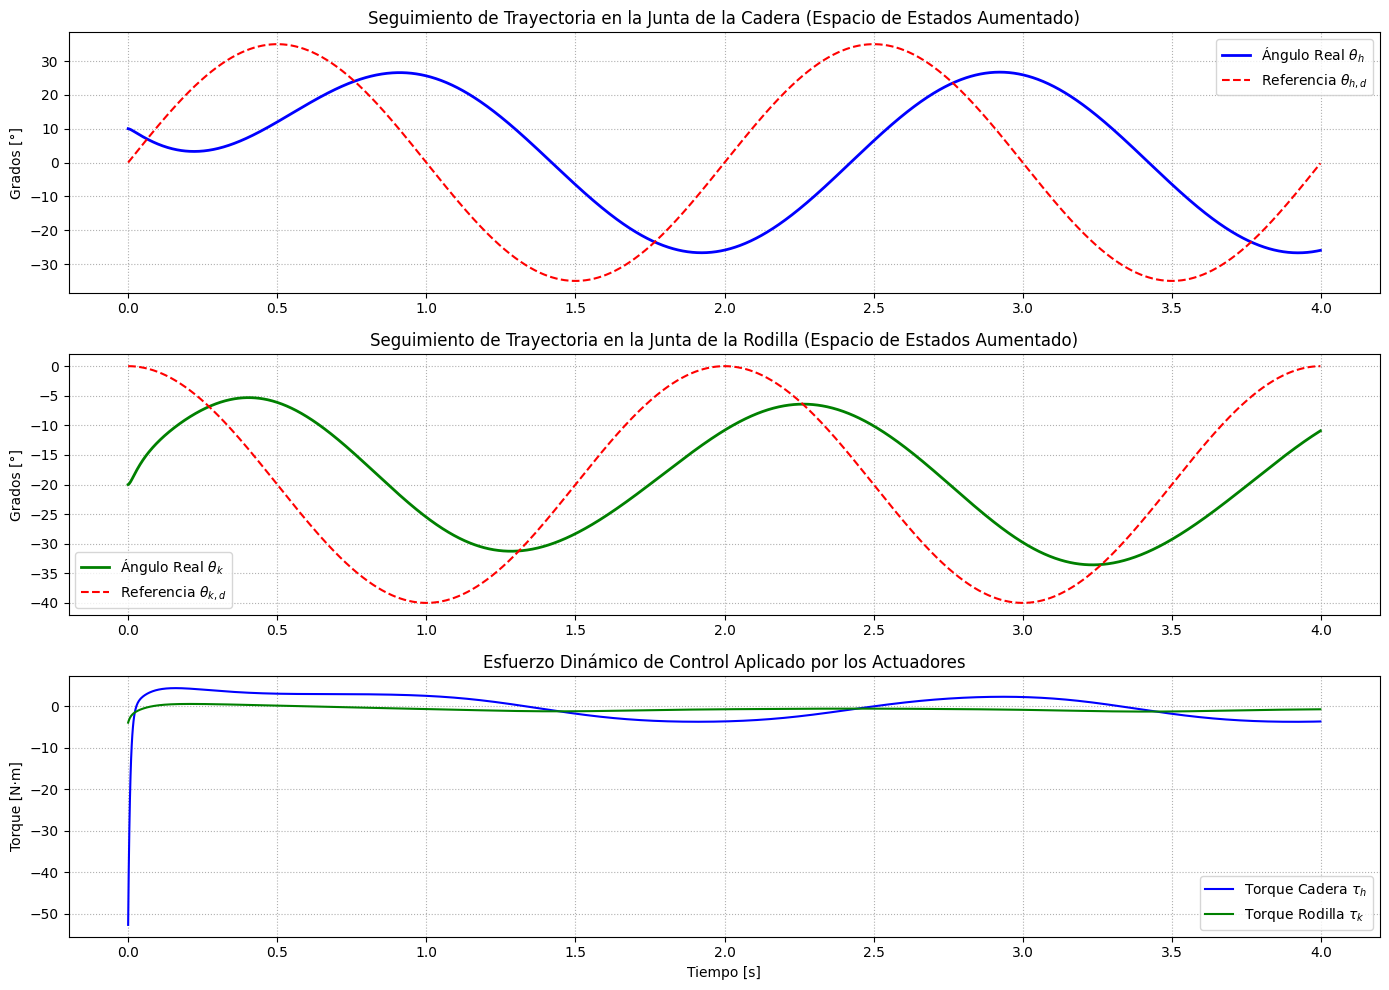


Mostrando animación física de la marcha controlada por asignación de polos (2 ciclos completos):


This browser does not support the video tag.


In [18]:
# ==============================================================================
# CELDA 6: EVALUACIÓN DE ESCENARIOS, TABLA COMPARATIVA Y GENERACIÓN DE ENTREGABLES
# ==============================================================================
controladores_a_evaluar = ['LAZO_ABIERTO', 'PID', 'FRECUENCIA', 'ESTADOS']
resultados_globales = {}
videos_guardados = {}

print("Iniciando simulaciones masivas en MuJoCo para el reporte del Control Day...")
for ctrl in controladores_a_evaluar:
    t, q_r, q_d, u_out, video_frames = simular_exoesqueleto(tipo_control=ctrl, T_sim=4.0)

    # Cálculo formal de las métricas estadísticas solicitadas en el proyecto
    err_cadera = q_r[:, 0] - q_d[:, 0]
    err_rodilla = q_r[:, 1] - q_d[:, 1]

    mae_c = np.mean(np.abs(err_cadera))
    mae_r = np.mean(np.abs(err_rodilla))
    rmse_c = np.sqrt(np.mean(err_cadera**2))
    rmse_r = np.sqrt(np.mean(err_rodilla**2))
    u_rms = np.sqrt(np.mean(u_out**2))
    u_max = np.max(np.abs(u_out))

    # Almacenar datos en el repositorio local de memoria
    resultados_globales[ctrl] = {
        't': t, 'q_r': q_r, 'q_d': q_d, 'u': u_out,
        'metrics': [mae_c, mae_r, rmse_c, rmse_r, u_rms, u_max]
    }
    videos_guardados[ctrl] = video_frames
    print(f" -> Simulación con esquema '{ctrl}' completada con éxito.")

# --- IMPRESIÓN AUTOMÁTICA DE LA TABLA COMPARATIVA FINAL ---
print("\n" + "="*85)
print("             TABLA COMPARATIVA DE DESEMPEÑO DEL EXOESQUELETO (EXPERIMENTO 6)")
print("="*85)
print(f"{'Controlador':<15} | {'MAE Cad':<7} | {'MAE Rod':<7} | {'RMSE Cad':<8} | {'RMSE Rod':<8} | {'Esf RMS':<7} | {'Esf Máx':<7}")
print("-"*85)
for ctrl, data in resultados_globales.items():
    m = data['metrics']
    print(f"{ctrl:<15} | {m[0]:.4f}  | {m[1]:.4f}  | {m[2]:.4f}   | {m[3]:.4f}   | {m[4]:.2f}   | {m[5]:.2f}")
print("="*85)

# --- GENERACIÓN DE GRÁFICAS COMPUESTAS DE RESPUESTA TEMPORAL ---
plt.figure(figsize=(14, 10))
data_target = resultados_globales['ESTADOS']  # Visualización por defecto de control moderno

plt.subplot(3, 1, 1)
plt.plot(data_target['t'], np.degrees(data_target['q_r'][:, 0]), 'b-', linewidth=2, label='Ángulo Real $\\theta_h$')
plt.plot(data_target['t'], np.degrees(data_target['q_d'][:, 0]), 'r--', linewidth=1.5, label='Referencia $\\theta_{h,d}$')
plt.title('Seguimiento de Trayectoria en la Junta de la Cadera (Espacio de Estados Aumentado)', fontsize=12)
plt.ylabel('Grados [°]')
plt.grid(True, linestyle=':')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(data_target['t'], np.degrees(data_target['q_r'][:, 1]), 'g-', linewidth=2, label='Ángulo Real $\\theta_k$')
plt.plot(data_target['t'], np.degrees(data_target['q_d'][:, 1]), 'r--', linewidth=1.5, label='Referencia $\\theta_{k,d}$')
plt.title('Seguimiento de Trayectoria en la Junta de la Rodilla (Espacio de Estados Aumentado)', fontsize=12)
plt.ylabel('Grados [°]')
plt.grid(True, linestyle=':')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(data_target['t'], data_target['u'][:, 0], 'b-', linewidth=1.5, label='Torque Cadera $\\tau_h$')
plt.plot(data_target['t'], data_target['u'][:, 1], 'g-', linewidth=1.5, label='Torque Rodilla $\\tau_k$')
plt.title('Esfuerzo Dinámico de Control Aplicado por los Actuadores', fontsize=12)
plt.xlabel('Tiempo [s]')
plt.ylabel('Torque [N·m]')
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.savefig('reporte_grafico_exoesqueleto.png', dpi=300)
plt.show()

# --- REPRODUCCIÓN DEL VIDEO DEL CICLO DE MARCHA ---
print("\nMostrando animación física de la marcha controlada por asignación de polos (2 ciclos completos):")
media.show_video(videos_guardados['ESTADOS'], fps=30)

In [19]:
# ============================================================
# MODELO DINÁMICO NO LINEAL
# ============================================================

def M_matrix(q):

    th_h, th_k = q

    M11 = (
        I_sh + I_th
        + l_ms**2*m_sh
        + l_mt**2*m_th
        + l_th**2*m_sh
        + 2*l_ms*l_th*m_sh*np.cos(th_k)
    )

    M12 = (
        I_sh
        + l_ms**2*m_sh
        + l_ms*l_th*m_sh*np.cos(th_k)
    )

    M22 = (
        I_sh
        + l_ms**2*m_sh
    )

    return np.array([
        [M11,M12],
        [M12,M22]
    ])


def C_matrix(q,dq):

    th_h, th_k = q
    dth_h, dth_k = dq

    C11 = -2*l_ms*l_th*m_sh*dth_k*np.sin(th_k)

    C12 = -l_ms*l_th*m_sh*dth_k*np.sin(th_k)

    C21 = l_ms*l_th*m_sh*dth_h*np.sin(th_k)

    return np.array([
        [C11,C12],
        [C21,0]
    ])


def G_vector(q):

    th_h, th_k = q

    G1 = (
        g*l_ms*m_sh*np.sin(th_h+th_k)
        + g*l_mt*m_th*np.sin(th_h)
        + g*l_th*m_sh*np.sin(th_h)
    )

    G2 = (
        g*l_ms*m_sh*np.sin(th_h+th_k)
    )

    return np.array([G1,G2])


print("Modelo dinámico no lineal cargado")

Modelo dinámico no lineal cargado


In [20]:
# ============================================================
# AUTOVALORES DEL SISTEMA
# ============================================================

eigA = np.linalg.eigvals(A)

print("Autovalores del sistema:")

for i,e in enumerate(eigA):
    print(f"λ{i+1} = {e}")

Autovalores del sistema:
λ1 = (2.5694443895723137e-17+5.955506069414614j)
λ2 = (2.5694443895723137e-17-5.955506069414614j)
λ3 = (3.0737246349182466e-16+2.6999717511792043j)
λ4 = (3.0737246349182466e-16-2.6999717511792043j)


In [21]:
# ============================================================
# ESTABILIDAD DEL CONTROLADOR POR ESTADOS
# ============================================================

Acl = A_aug - B_aug @ K_total

eig_cl = np.linalg.eigvals(Acl)

print("Polos del sistema controlado")

for p in eig_cl:
    print(p)

Polos del sistema controlado
-5.500000000001023
-8.00000000000195
-5.9999999999998055
-6.500000000001259
-7.49999999999891
-6.999999999996624


In [22]:
from scipy import signal

# ============================================================
# CONTROLADOR ADELANTO
# ============================================================

K = 15

T = 0.15

alpha = 0.15

numC = K*np.array([T,1])

denC = np.array([alpha*T,1])

Clead = signal.TransferFunction(
    numC,
    denC
)

print(Clead)

TransferFunctionContinuous(
array([100.        , 666.66666667]),
array([ 1.        , 44.44444444]),
dt: None
)


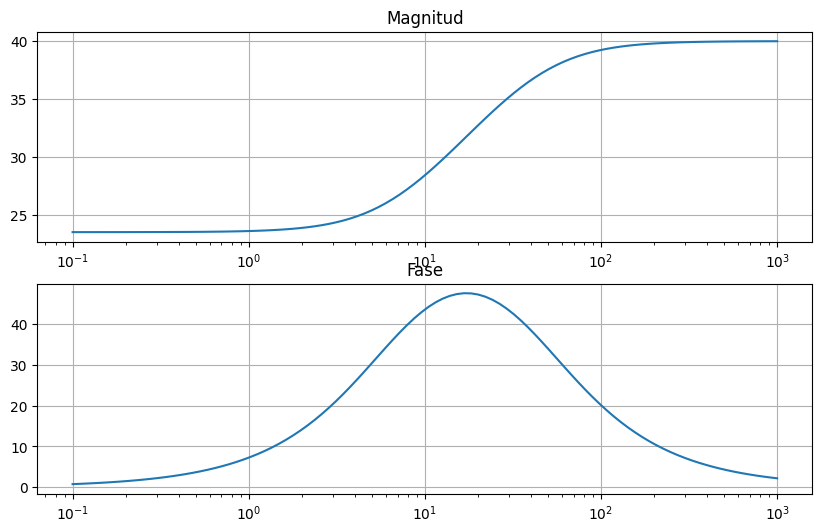

In [23]:
# ============================================================
# BODE
# ============================================================

w, mag, phase = signal.bode(Clead)

plt.figure(figsize=(10,6))

plt.subplot(211)
plt.semilogx(w,mag)
plt.grid()

plt.title("Magnitud")

plt.subplot(212)
plt.semilogx(w,phase)
plt.grid()

plt.title("Fase")

plt.show()

In [26]:
import control as ct

Gc = ct.TransferFunction(
    numC,
    denC
)

gm, pm, wcg, wcp = ct.margin(Gc)

print("Margen de ganancia:",gm)
print("Margen de fase:",pm)
print("Frecuencia cruce ganancia:",wcg)
print("Frecuencia cruce fase:",wcp)

Margen de ganancia: inf
Margen de fase: inf
Frecuencia cruce ganancia: nan
Frecuencia cruce fase: nan


In [27]:
# ============================================================
# EXPORTAR VIDEOS
# ============================================================

media.write_video(
    "marcha_lazo_abierto.mp4",
    videos_guardados["LAZO_ABIERTO"],
    fps=30
)

media.write_video(
    "marcha_pid.mp4",
    videos_guardados["PID"],
    fps=30
)

media.write_video(
    "marcha_estados.mp4",
    videos_guardados["ESTADOS"],
    fps=30
)

print("Videos exportados")

Videos exportados


In [30]:
resultados = {}
videos_guardados = {}

for ctrl in ["LAZO_ABIERTO", "PID", "ESTADOS"]:

    print(f"Simulando {ctrl}...")

    t, q, q_d, u, frames = simular_exoesqueleto(
        tipo_control=ctrl,
        T_sim=4.0
    )

    resultados[ctrl] = {
        "t": t,
        "q": q,
        "q_d": q_d,
        "u": u
    }

    videos_guardados[ctrl] = frames

Simulando LAZO_ABIERTO...
Simulando PID...
Simulando ESTADOS...


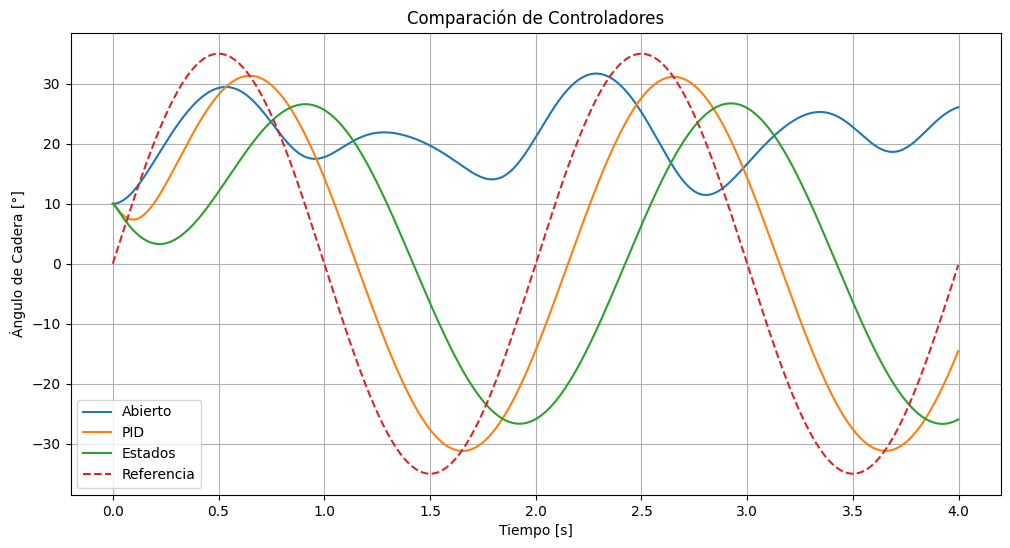

In [31]:
# ============================================================
# COMPARACIÓN FINAL
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    resultados["LAZO_ABIERTO"]["t"],
    np.degrees(
        resultados["LAZO_ABIERTO"]["q"][:,0]
    ),
    label="Abierto"
)

plt.plot(
    resultados["PID"]["t"],
    np.degrees(
        resultados["PID"]["q"][:,0]
    ),
    label="PID"
)

plt.plot(
    resultados["ESTADOS"]["t"],
    np.degrees(
        resultados["ESTADOS"]["q"][:,0]
    ),
    label="Estados"
)

plt.plot(
    resultados["ESTADOS"]["t"],
    np.degrees(
        resultados["ESTADOS"]["q_d"][:,0]
    ),
    '--',
    label="Referencia"
)

plt.grid()
plt.legend()
plt.title("Comparación de Controladores")
plt.ylabel("Ángulo de Cadera [°]")
plt.xlabel("Tiempo [s]")

plt.show()

In [32]:
# ============================================================
# TORQUES DE EQUILIBRIO
# ============================================================

u0 = np.array([
    3.7231,
    -0.8093
])

print("Torque nominal cadera :",u0[0],"Nm")
print("Torque nominal rodilla:",u0[1],"Nm")

Torque nominal cadera : 3.7231 Nm
Torque nominal rodilla: -0.8093 Nm
